# SVR

## Simple English: SVM vs SVR
- **SVM (Support Vector Machine)** is mostly used for classification (predicting classes like Yes/No).
- **SVR (Support Vector Regression)** is the regression version of SVM (predicting continuous numbers).

### Intuition
SVR tries to draw a best-fit line (or curve) with a margin (called epsilon tube).
- Errors inside the tube are ignored.
- Errors outside the tube are penalized.

In simple English: SVR tries to keep predictions close to actual values, but allows a small safe error band.

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 2: Create Synthetic Regression Dataset with `make_regression`

In [2]:
X, y = make_regression(
    n_samples=1000,
    n_features=7,
    noise=25,
    random_state=42
)

feature_names = [f'feature_{i+1}' for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name='target')

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)
display(X.head())
print('\nTarget sample values:')
print(y.head())

Shape of X: (1000, 7)
Shape of y: (1000,)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7
0,0.058984,-0.342549,0.446873,-0.658248,0.170464,-0.982294,0.453509
1,-0.847634,-1.089633,-0.652089,0.397927,-0.784762,-0.218046,1.809306
2,-0.898468,-0.009119,0.028181,-0.174960,1.085896,0.536510,-0.755745
3,-0.214955,0.702660,0.385750,-0.719990,0.240877,-1.253506,-0.924063
4,-0.552921,-0.497571,1.001825,-0.975366,-0.782003,0.664703,1.303508



Target sample values:
0    -68.238632
1   -136.515083
2     -2.923684
3      2.465606
4    -64.745979
Name: target, dtype: float64


## Step 3: Quick Data Check

In [3]:
print('Missing values per column:')
print(X.isnull().sum())

print('\nTarget summary:')
print(y.describe())

Missing values per column:
feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
feature_6    0
feature_7    0
dtype: int64

Target summary:
count    1000.000000
mean        2.587185
std       121.949898
min      -399.873366
25%       -78.912940
50%         0.294442
75%        90.180607
max       421.088954
Name: target, dtype: float64


## Step 4: Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 800
Testing samples: 200


## Step 5: Build SVR Pipeline
SVR is sensitive to feature scale, so we use StandardScaler before SVR.

In [6]:
svr_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=100, epsilon=1, gamma=0.01))
])

## Step 6: Train and Predict

In [7]:
svr_pipeline.fit(X_train, y_train)
y_pred = svr_pipeline.predict(X_test)

print('First 5 predictions:', y_pred[:5])

First 5 predictions: [ 80.35203832 -59.64557336 139.22051757 -44.67024574 131.22560575]


## Step 7: Important Scores
- MAE: average absolute error (lower is better)
- RMSE: penalizes large errors more (lower is better)
- R2: explained variance score (closer to 1 is better)

In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

scores_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Value': [mae, rmse, r2]
})

display(scores_df)
print(f'MAE:  {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R2:   {r2:.4f}')

,Metric,Value
0,MAE,21.353578
1,RMSE,27.697667
2,R2,0.947422


MAE:  21.354
RMSE: 27.698
R2:   0.9474


## Step 8: Graphs for Model Performance

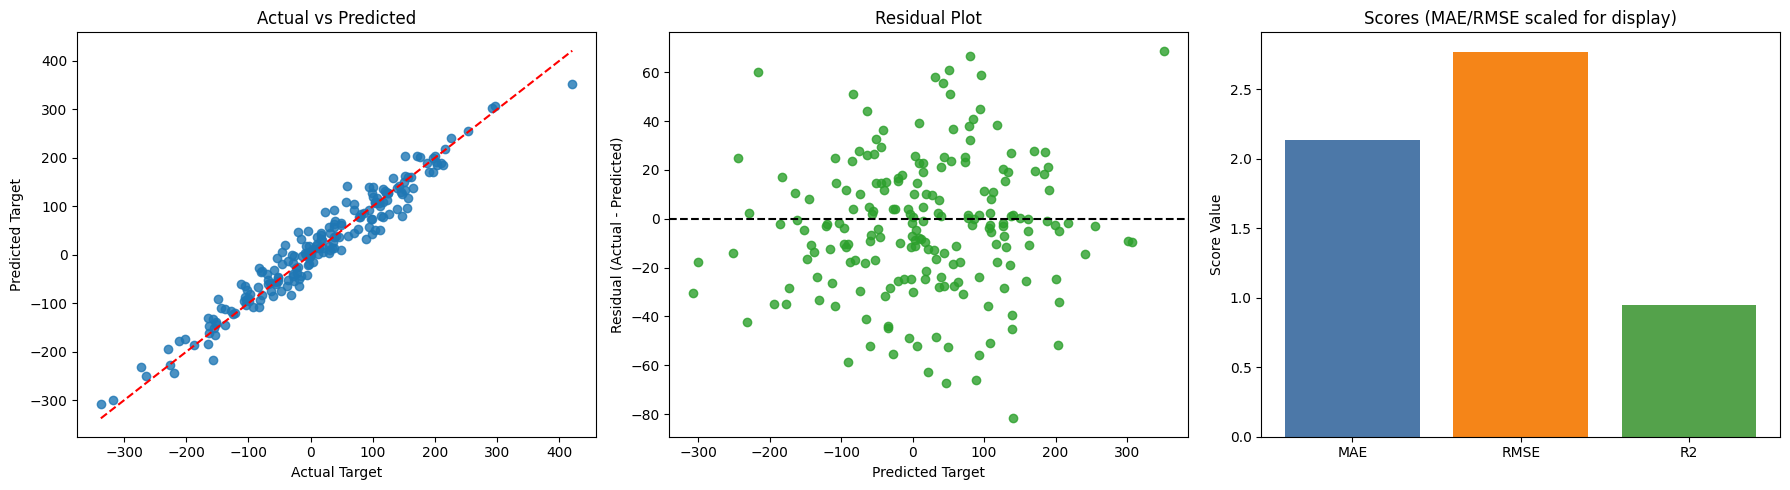

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='tab:blue', alpha=0.8)
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], 'r--')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Target')
axes[0].set_ylabel('Predicted Target')

# 2) Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='tab:green', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Target')
axes[1].set_ylabel('Residual (Actual - Predicted)')

# 3) Scores bar chart
plot_scores = scores_df.copy()
mae_rmse_mask = plot_scores['Metric'].isin(['MAE', 'RMSE'])
plot_scores.loc[mae_rmse_mask, 'Value'] = plot_scores.loc[mae_rmse_mask, 'Value'] / 10
axes[2].bar(plot_scores['Metric'], plot_scores['Value'], color=['#4c78a8', '#f58518', '#54a24b'])
axes[2].set_title('Scores (MAE/RMSE scaled for display)')
axes[2].set_ylabel('Score Value')

plt.tight_layout()
plt.show()

## Step 9: Compare a Few Actual vs Predicted Values

In [10]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
comparison_df['Absolute_Error'] = (comparison_df['Actual'] - comparison_df['Predicted']).abs()
display(comparison_df.head(10))

,Actual,Predicted,Absolute_Error
0,146.803506,80.352038,66.451467
1,-111.690535,-59.645573,52.044962
2,99.637598,139.220518,39.582920
3,-15.230399,-44.670246,29.439847
4,119.810784,131.225606,11.414821
5,-69.011313,-51.925079,17.086234
6,109.903489,107.631812,2.271677
7,31.756412,8.972086,22.784326
8,76.744616,53.214249,23.530367
9,9.642972,37.402406,27.759434


## Simple English Summary
- SVM is for classification, SVR is for regression.
- We scaled features and trained SVR with RBF kernel.
- MAE, RMSE, and R2 tell us how good the predictions are.
- Graphs help you understand closeness of predictions and error behavior.